# CV split audit — `stratify="both"` across the BiasOnDemand datasets

Same audit as `benchmark/real_datasets/analyze_splits.ipynb`, applied to the 9 synthetic
datasets generated by `run.ipynb`. No models, no metrics. Just inspect what the splitter
does on each dataset under `stratify="both"` and surface where (and why) fairness metrics
will be undefined.

**Two questions:**

1. **Stratification fallback** — does `stratify="both"` collapse to `stratify="y"` (or further)
   for any dataset? Predicted by `smallest joint (Y, A) cell < n_splits`, verified by calling
   the runner's private helpers.
2. **Fold-level positive starvation** — *beyond* fallback, do any test folds end up with zero
   actual positives in either group? Ratio fairness metrics (`disparate_impact`,
   `equal_opportunity_ratio`, `predictive_equality`) are NaN whenever this happens, even when
   stratification itself "succeeded".

The 432 `TPR is undefined` warnings yesterday's run produced are this second issue, not
fallback — and we want both characterised before tomorrow's discussion of fallback strategy.

> Convention note. `run.ipynb` sets `priv_group=1`, so skfair treats `A=1` as the *privileged*
> group. BiasOnDemand's own docstrings call `A=1` the *unprivileged* / undersampled group.
> The audit below uses skfair's convention (`A=1` = privileged) so it matches what
> `Experiment` actually computed; the convention mismatch itself is a separate question,
> noted in the takeaways.

In [1]:
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skfair.experimentation._runner import _resolve_strat_label, _build_splits

DATASETS_DIR = Path("datasets")
CONCAT_DIR = DATASETS_DIR / "concat"
N_SPLITS = 5
RANDOM_STATE = 42

NAMES = [
    "hist_low",  "hist_med",  "hist_high",
    "meas_low",  "meas_med",  "meas_high",
    "repr_low",  "repr_med",  "repr_high",
]
SENS_COL = "A"
PRIV = 1   # mirrors run.ipynb's load_dataset

def load(name):
    df = pd.read_csv(CONCAT_DIR / f"{name}.csv")
    y = df["Y"].astype(int).values
    X = df.drop(columns=["Y"])
    return X, y

# Sanity check that all 9 files load
[(n, load(n)[0].shape) for n in NAMES]

[('hist_low', (1000, 3)),
 ('hist_med', (1000, 3)),
 ('hist_high', (1000, 3)),
 ('meas_low', (1000, 3)),
 ('meas_med', (1000, 3)),
 ('meas_high', (1000, 3)),
 ('repr_low', (880, 3)),
 ('repr_med', (761, 3)),
 ('repr_high', (641, 3))]

## 1. Pre-CV audit — joint (Y, A) cell counts

The smallest joint cell must be `≥ n_splits = 5` for full `stratify="both"` to succeed.
If it's smaller, the runner emits a `UserWarning` and falls back to `stratify="y"`.

In [2]:
audit_rows = []
joint_tables = {}

for name in NAMES:
    X, y = load(name)
    sens = X[SENS_COL].values

    joint = (
        pd.DataFrame({'Y': y, SENS_COL: sens})
        .value_counts()
        .sort_index()
        .rename('count')
    )
    joint_tables[name] = joint.to_frame()

    audit_rows.append({
        'dataset': name,
        'n_rows': len(y),
        'y_pos_rate': float((y == 1).mean()),
        'sens_priv_rate': float((sens == PRIV).mean()),
        'n_joint_cells': len(joint),
        'smallest_joint_cell': int(joint.min()),
        'predicted_fallback': int(joint.min()) < N_SPLITS,
    })

audit = pd.DataFrame(audit_rows).set_index('dataset')
audit.round(3)

,n_rows,y_pos_rate,sens_priv_rate,n_joint_cells,smallest_joint_cell,predicted_fallback
dataset,,,,,,
hist_low,1000,0.481,0.478,4,141,False
hist_med,1000,0.486,0.478,4,126,False
hist_high,1000,0.486,0.478,4,108,False
meas_low,1000,0.486,0.478,4,126,False
meas_med,1000,0.486,0.478,4,126,False
meas_high,1000,0.486,0.478,4,126,False
repr_low,880,0.480,0.407,4,58,False
repr_med,761,0.485,0.314,4,20,False
repr_high,641,0.490,0.186,4,2,True


In [3]:
for name, df in joint_tables.items():
    print(f'=== {name} ===')
    display(df)

=== hist_low ===


count
Y A       
0 0    182
  1    337
1 0    340
  1    141

=== hist_med ===


count
Y A       
0 0    162
  1    352
1 0    360
  1    126

=== hist_high ===


...

count
Y A       
0 0    158
  1    300
1 0    364
  1     58

=== repr_med ===


count
Y A       
0 0    173
  1    219
1 0    349
  1     20

=== repr_high ===


count
Y A       
0 0    210
  1    117
1 0    312
  1      2

## 2. Run the actual splitter — does fallback trigger?

Call `_build_splits` with `stratify="both"` and capture any warnings. The runner
warns with `"falling back to stratify='y'"` whenever it has to degrade.

In [4]:
splits_per_dataset = {}
fallback_rows = []

for name in NAMES:
    X, y = load(name)
    y_arr = np.asarray(y)

    label = _resolve_strat_label('both', y_arr, X, SENS_COL)

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        splits = _build_splits(
            n_splits=N_SPLITS, n_repeats=1,
            strat_label=label, y_arr=y_arr, random_state=RANDOM_STATE,
        )
        fallback = any('falling back' in str(w.message) for w in caught)
        warning_text = '; '.join(str(w.message) for w in caught) or '—'

    splits_per_dataset[name] = (splits, label, fallback)
    fallback_rows.append({
        'dataset':           name,
        'n_folds_obtained':  len(splits),
        'fallback_to_y':     fallback,
        'warning':           warning_text,
    })

pd.DataFrame(fallback_rows).set_index('dataset')

,n_folds_obtained,fallback_to_y,warning
dataset,,,
hist_low,5,False,—
hist_med,5,False,—
hist_high,5,False,—
meas_low,5,False,—
meas_med,5,False,—
meas_high,5,False,—
repr_low,5,False,—
repr_med,5,False,—
repr_high,5,True,Stratification failed: a stratum has fewer mem...


## 3. Per-fold composition (test sets)

For each dataset, count the (Y, A) cells in each fold's **test** indices.
A well-stratified fold has every cell represented at roughly equal counts.
Where `repr_high` falls back to `stratify='y'`, group counts are no longer guaranteed
balanced fold-to-fold — which is also where ratio metrics start to break.

In [5]:
for name in NAMES:
    X, y = load(name)
    y_arr = np.asarray(y)
    sens = np.asarray(X[SENS_COL])

    splits, label, fallback = splits_per_dataset[name]

    rows = []
    for _, test_idx in splits:
        cnt = Counter(zip(y_arr[test_idx], sens[test_idx]))
        rows.append({
            **{f'(Y={k[0]}, A={k[1]})': cnt[k] for k in sorted(cnt)},
            'fold_size': len(test_idx),
        })
    df = pd.DataFrame(rows).fillna(0).astype(int)
    df.index.name = (
        f'fold ({"FELL BACK to stratify=y" if fallback else "stratify=both succeeded"})'
    )
    print(f'=== {name} ===')
    display(df)

=== hist_low ===


,"(Y=0, A=0)","(Y=0, A=1)","(Y=1, A=0)","(Y=1, A=1)",fold_size
fold (stratify=both succeeded),,,,,
0,37,67,68,28,200
1,37,67,68,28,200
2,36,67,68,29,200
3,36,68,68,28,200
4,36,68,68,28,200


=== hist_med ===


,"(Y=0, A=0)","(Y=0, A=1)","(Y=1, A=0)","(Y=1, A=1)",fold_size
fold (stratify=both succeeded),,,,,
0,33,70,72,25,200
1,33,70,72,25,200
2,32,70,72,26,200
3,32,71,72,25,200
4,32,71,72,25,200


=== hist_high ===


...

,"(Y=0, A=0)","(Y=0, A=1)","(Y=1, A=0)","(Y=1, A=1)",fold_size
fold (stratify=both succeeded),,,,,
0,32,60,73,11,176
1,32,60,73,11,176
2,31,60,73,12,176
3,31,60,73,12,176
4,32,60,72,12,176


=== repr_med ===


,"(Y=0, A=0)","(Y=0, A=1)","(Y=1, A=0)","(Y=1, A=1)",fold_size
fold (stratify=both succeeded),,,,,
0,35,44,70,4,153
1,35,44,69,4,152
2,35,43,70,4,152
3,34,44,70,4,152
4,34,44,70,4,152


=== repr_high ===


,"(Y=0, A=0)","(Y=0, A=1)","(Y=1, A=0)",fold_size,"(Y=1, A=1)"
fold (FELL BACK to stratify=y),,,,,
0,43,23,63,129,0
1,38,27,63,128,0
2,36,29,63,128,0
3,44,21,62,128,1
4,49,17,61,128,1


## 4. Bias-parameter sweep — picking a viable `repr_high p_u`

The audit above shows that at `p_u=0.25, l_r=True` (the current `repr_high`
config) the `(Y=1, A=1)` cell collapses to 2 — three of the 5 test folds end up
with **zero** privileged positives, and ratio fairness metrics are NaN by
construction.

This section runs `biasondemand.generate_dataset` for `p_u ∈ {0.10, …, 0.50}` on
both `l_r=True` (informed undersampling, what the existing track uses) and
`l_r=False` (random undersampling), and reports the resulting `(Y=1, A=1)` cell
size. The goal is to find a parameter regime where every test fold has at least
one privileged positive, so ratios stay defined.

> Each probe is generated in an isolated temp directory; the real
> `datasets/raw/` and `datasets/concat/` trees are not touched.

In [6]:
import contextlib, io, os, shutil, tempfile

import biasondemand

SWEEP_PU = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
SWEEP_LR = [True, False]
SWEEP_DIM = 1000

def _probe(p_u, l_r, dim=SWEEP_DIM):
    """Generate one BiasOnDemand sample with l_m=0 in a temp dir, return cell counts."""
    tmp = Path(tempfile.mkdtemp(prefix='bod_probe_'))
    cwd = os.getcwd()
    try:
        os.chdir(tmp)
        with contextlib.redirect_stdout(io.StringIO()):
            biasondemand.generate_dataset(
                path='probe', dim=dim, l_r=l_r, p_u=p_u, l_m=0,
            )
        folder = tmp / 'datasets' / 'probe'
        Xtr = pd.read_csv(folder / 'X_train.csv', index_col=0)
        Xte = pd.read_csv(folder / 'X_test.csv',  index_col=0)
        ytr = pd.read_csv(folder / 'y_train.csv', index_col=0)['Y']
        yte = pd.read_csv(folder / 'y_test.csv',  index_col=0)['Y']
        X = pd.concat([Xtr, Xte], ignore_index=True)
        y = pd.concat([ytr, yte], ignore_index=True).astype(int)
        ct = pd.crosstab(y, X['A'])
        cell = int(ct.loc[1, 1]) if (1 in ct.index and 1 in ct.columns) else 0
        return {
            'l_r': l_r, 'p_u': p_u,
            'n_total': len(y),
            'n_A=1': int((X['A'] == 1).sum()),
            '(Y=1,A=1)': cell,
            'per_5fold': round(cell / 5, 2),
        }
    finally:
        os.chdir(cwd)
        shutil.rmtree(tmp, ignore_errors=True)

sweep_rows = [_probe(p_u, l_r) for l_r in SWEEP_LR for p_u in SWEEP_PU]
sweep = pd.DataFrame(sweep_rows)
sweep

,l_r,p_u,n_total,n_A=1,"(Y=1,A=1)",per_5fold
0,True,0.10,569,47,0,0.0
1,True,0.15,593,71,0,0.0
2,True,0.20,617,95,0,0.0
3,True,0.25,641,119,2,0.4
4,True,0.30,665,143,4,0.8
5,True,0.35,689,167,6,1.2
6,True,0.40,713,191,8,1.6
7,True,0.45,737,215,16,3.2
8,True,0.50,761,239,20,4.0
9,False,0.10,569,47,4,0.8


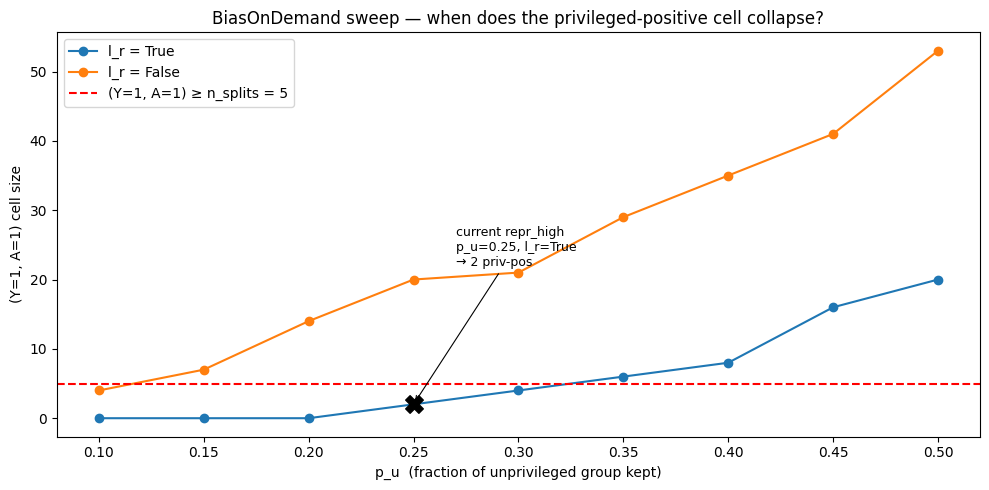

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for l_r in SWEEP_LR:
    sub = sweep[sweep['l_r'] == l_r].sort_values('p_u')
    ax.plot(sub['p_u'], sub['(Y=1,A=1)'], marker='o',
            label=f'l_r = {l_r}')

ax.axhline(N_SPLITS, color='red', ls='--',
           label=f'(Y=1, A=1) ≥ n_splits = {N_SPLITS}')

# Mark current repr_high (p_u=0.25, l_r=True → 2)
cur = sweep.query('l_r == True and p_u == 0.25')
if not cur.empty:
    ax.scatter(cur['p_u'], cur['(Y=1,A=1)'],
               s=160, marker='X', color='black', zorder=5)
    ax.annotate(
        f"current repr_high\np_u=0.25, l_r=True\n→ {int(cur['(Y=1,A=1)'].iloc[0])} priv-pos",
        xy=(0.25, int(cur['(Y=1,A=1)'].iloc[0])), xytext=(0.27, 22), fontsize=9,
        arrowprops=dict(arrowstyle='->', lw=0.8),
    )

ax.set_xlabel('p_u  (fraction of unprivileged group kept)')
ax.set_ylabel('(Y=1, A=1) cell size')
ax.set_title('BiasOnDemand sweep — when does the privileged-positive cell collapse?')
ax.legend()
plt.tight_layout()
plt.show()

fix - increase p_u


or change l_r

l_r=true removes privileged positives,  false is random undersampling
